In [1]:
from dataclasses import dataclass
from typing import List
import math
import random

@dataclass
class Bucket:
    size: int      # number of 1s this bucket represents
    end_time: int  # timestamp of the most recent 1 in this bucket

class DGIM:
    def __init__(self, window_size: int):
        if window_size <= 0:
            raise ValueError("window_size must be positive")
        self.W = window_size
        self.time = 0
        self.buckets: List[Bucket] = []  # newest first

    def _expire(self):
        """Drop buckets that are completely outside the sliding window."""
        boundary = self.time - self.W
        self.buckets = [b for b in self.buckets if b.end_time > boundary]

    def _compress(self):
        """Ensure ≤2 buckets per size by merging the oldest ones if necessary."""
        i = 0
        while i < len(self.buckets):
            size_i = self.buckets[i].size
            j = i
            count = 0
            while j < len(self.buckets) and self.buckets[j].size == size_i:
                count += 1
                j += 1
            while count > 2:
                b_oldest = self.buckets.pop(j-1)
                b_second_oldest = self.buckets.pop(j-2)
                merged = Bucket(size=b_oldest.size * 2, end_time=b_second_oldest.end_time)
                self.buckets.insert(j-2, merged)
                # restart check from here
                i = max(0, i-1)
                break
            else:
                i = j

    def add(self, bit: int):
        """Add the next bit from the stream."""
        if bit not in (0, 1):
            raise ValueError("bit must be 0 or 1")
        self.time += 1
        if bit == 1:
            self.buckets.insert(0, Bucket(size=1, end_time=self.time))
            self._compress()
        self._expire()

    def query(self, k: int) -> int:
        """Estimate the number of 1s in the last k bits (k ≤ W)."""
        if k <= 0:
            return 0
        if k > self.W:
            k = self.W
        threshold = self.time - k
        total = 0
        partial_added = False
        for b in self.buckets:
            if b.end_time <= threshold:
                continue
            if not partial_added:
                oldest_partial = b
                partial_added = True
            else:
                total += b.size
        if partial_added:
            total += math.ceil(oldest_partial.size / 2)
        return total


# ---------------- Demo ----------------
if __name__ == "__main__":
    dg = DGIM(window_size=100)
    stream = [random.choice([0,1]) for _ in range(200)]

    for bit in stream:
        dg.add(bit)

    k = 50
    approx = dg.query(k)
    exact = sum(stream[-k:])
    print(f"DGIM estimate of 1s in last {k} bits: {approx}")
    print(f"Exact count: {exact}")


DGIM estimate of 1s in last 50 bits: 33
Exact count: 26


In [3]:
import random
import math
from dataclasses import dataclass
from typing import List

@dataclass
class Bucket:
    size: int
    end_time: int

class DGIM:
    def __init__(self, window_size: int):
        self.W = window_size
        self.time = 0
        self.buckets: List[Bucket] = []

    def _expire(self):
        boundary = self.time - self.W
        self.buckets = [b for b in self.buckets if b.end_time > boundary]

    def _compress(self):
        i = 0
        while i < len(self.buckets):
            size_i = self.buckets[i].size
            j = i
            count = 0
            while j < len(self.buckets) and self.buckets[j].size == size_i:
                count += 1
                j += 1
            while count > 2:
                b_oldest = self.buckets.pop(j-1)
                b_second_oldest = self.buckets.pop(j-2)
                merged = Bucket(size=b_oldest.size * 2, end_time=b_second_oldest.end_time)
                self.buckets.insert(j-2, merged)
                i = max(0, i-1)
                break
            else:
                i = j

    def add(self, bit: int):
        self.time += 1
        if bit == 1:
            self.buckets.insert(0, Bucket(size=1, end_time=self.time))
            self._compress()
        self._expire()

    def query(self, k: int) -> int:
        if k <= 0: return 0
        if k > self.W: k = self.W
        threshold = self.time - k
        total = 0
        partial_added = False
        for b in self.buckets:
            if b.end_time <= threshold:
                continue
            if not partial_added:
                oldest_partial = b
                partial_added = True
            else:
                total += b.size
        if partial_added:
            total += math.ceil(oldest_partial.size / 2)
        return total

    def show_buckets(self):
        """Display buckets with their size and covered bit indices."""
        print("Buckets (newest → oldest):")
        for b in self.buckets:
            start_index = b.end_time - b.size + 1
            indices = list(range(start_index, b.end_time+1))
            print(f"  size={b.size}, covers bit indices {indices}")
        if not self.buckets:
            print("  [no buckets]")

# ---------------- Interactive Demo ----------------

# Generate random 80-bit stream
stream = [random.choice([0,1]) for _ in range(80)]
print("Random stream of 80 bits:")
print(stream)

dg = DGIM(window_size=80)

# Feed user-supplied bits one at a time
while True:
    bit_in = input("Enter next bit (0/1) or 'q' to stop: ")
    if bit_in.lower() == 'q':
        break
    if bit_in not in ('0', '1'):
        print("Please enter 0 or 1.")
        continue

    bit = int(bit_in)
    dg.add(bit)
    print(f"Added bit {bit} at time {dg.time}")
    dg.show_buckets()

# After feeding bits, ask for query
k = int(input("Enter number of last bits to query (k): "))
print(f"Approximate number of 1s in last {k} bits: {dg.query(k)}")


Random stream of 80 bits:
[0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1]
Enter next bit (0/1) or 'q' to stop: 0
Added bit 0 at time 1
Buckets (newest → oldest):
  [no buckets]
Enter next bit (0/1) or 'q' to stop: 1
Added bit 1 at time 2
Buckets (newest → oldest):
  size=1, covers bit indices [2]
Enter next bit (0/1) or 'q' to stop: 1
Added bit 1 at time 3
Buckets (newest → oldest):
  size=1, covers bit indices [3]
  size=1, covers bit indices [2]
Enter next bit (0/1) or 'q' to stop: 4
Please enter 0 or 1.
Enter next bit (0/1) or 'q' to stop: 0
Added bit 0 at time 4
Buckets (newest → oldest):
  size=1, covers bit indices [3]
  size=1, covers bit indices [2]
Enter next bit (0/1) or 'q' to stop: 1
Added bit 1 at time 5
Buckets (newest → oldest):
  size=1, covers bit indices [5]
  size=2, covers bit

In [4]:
import math
from dataclasses import dataclass
from typing import List

@dataclass
class Bucket:
    size: int
    end_time: int

class DGIM:
    def __init__(self, window_size: int):
        self.W = window_size
        self.time = 0
        self.buckets: List[Bucket] = []

    def _expire(self):
        boundary = self.time - self.W
        self.buckets = [b for b in self.buckets if b.end_time > boundary]

    def _compress(self):
        i = 0
        while i < len(self.buckets):
            size_i = self.buckets[i].size
            j = i
            count = 0
            while j < len(self.buckets) and self.buckets[j].size == size_i:
                count += 1
                j += 1
            while count > 2:
                b_oldest = self.buckets.pop(j-1)
                b_second_oldest = self.buckets.pop(j-2)
                merged = Bucket(size=b_oldest.size * 2, end_time=b_second_oldest.end_time)
                self.buckets.insert(j-2, merged)
                i = max(0, i-1)
                break
            else:
                i = j

    def add(self, bit: int):
        self.time += 1
        if bit == 1:
            self.buckets.insert(0, Bucket(size=1, end_time=self.time))
            self._compress()
        self._expire()

    def show_buckets(self):
        print("\nCurrent Buckets:")
        print(f"{'Bucket#':<8}{'Size':<6}{'Bit indices':<20}{'Timestamp (end)':<15}")
        for idx, b in enumerate(self.buckets, start=1):
            start_index = b.end_time - b.size + 1
            indices = list(range(start_index, b.end_time + 1))
            print(f"{idx:<8}{b.size:<6}{str(indices):<20}{b.end_time:<15}")
        if not self.buckets:
            print("  [No buckets]")

# ---------------- 15-bit Interactive Demo ----------------

dg = DGIM(window_size=15)

print("Enter 15 bits one by one (0 or 1):")
for i in range(15):
    while True:
        bit_in = input(f"Enter bit {i+1} (0/1): ")
        if bit_in in ('0', '1'):
            bit = int(bit_in)
            break
        else:
            print("Please enter 0 or 1.")
    dg.add(bit)
    print(f"\nAdded bit {bit} at time {dg.time}")
    dg.show_buckets()



Enter 15 bits one by one (0 or 1):
Enter bit 1 (0/1): 1

Added bit 1 at time 1

Current Buckets:
Bucket# Size  Bit indices         Timestamp (end)
1       1     [1]                 1              
Enter bit 2 (0/1): 0

Added bit 0 at time 2

Current Buckets:
Bucket# Size  Bit indices         Timestamp (end)
1       1     [1]                 1              
Enter bit 3 (0/1): 0

Added bit 0 at time 3

Current Buckets:
Bucket# Size  Bit indices         Timestamp (end)
1       1     [1]                 1              
Enter bit 4 (0/1): 1

Added bit 1 at time 4

Current Buckets:
Bucket# Size  Bit indices         Timestamp (end)
1       1     [4]                 4              
2       1     [1]                 1              
Enter bit 5 (0/1): 1

Added bit 1 at time 5

Current Buckets:
Bucket# Size  Bit indices         Timestamp (end)
1       1     [5]                 5              
2       2     [3, 4]              4              
Enter bit 6 (0/1): 1

Added bit 1 at time 6

Current Bu

KeyboardInterrupt: Interrupted by user

In [5]:
import math
from dataclasses import dataclass
from typing import List

@dataclass
class Bucket:
    size: int
    end_time: int

class DGIM:
    def __init__(self, window_size: int):
        self.W = window_size
        self.time = 0
        self.buckets: List[Bucket] = []
        self.sequence = []  # Keep actual sequence for exact counts

    def _expire(self):
        boundary = self.time - self.W
        self.buckets = [b for b in self.buckets if b.end_time > boundary]

    def _compress(self):
        i = 0
        while i < len(self.buckets):
            size_i = self.buckets[i].size
            j = i
            count = 0
            while j < len(self.buckets) and self.buckets[j].size == size_i:
                count += 1
                j += 1
            while count > 2:
                b_oldest = self.buckets.pop(j-1)
                b_second_oldest = self.buckets.pop(j-2)
                merged = Bucket(size=b_oldest.size * 2, end_time=b_second_oldest.end_time)
                self.buckets.insert(j-2, merged)
                i = max(0, i-1)
                break
            else:
                i = j

    def add(self, bit: int):
        self.time += 1
        self.sequence.append(bit)
        if bit == 1:
            self.buckets.insert(0, Bucket(size=1, end_time=self.time))
            self._compress()
        self._expire()

    def show_buckets(self):
        print("\nCurrent Buckets:")
        print(f"{'Bucket#':<8}{'Size':<6}{'Bit indices':<20}{'Timestamp (end)':<15}")
        for idx, b in enumerate(self.buckets, start=1):
            start_index = b.end_time - b.size + 1
            indices = list(range(start_index, b.end_time + 1))
            print(f"{idx:<8}{b.size:<6}{str(indices):<20}{b.end_time:<15}")
        if not self.buckets:
            print("  [No buckets]")

    def query(self, k: int) -> int:
        """Approximate count of 1s in last k bits"""
        total = 0
        boundary = self.time - k
        for i, b in enumerate(self.buckets):
            if b.end_time <= boundary:
                continue
            if b.end_time - b.size + 1 > boundary:
                total += b.size
            else:
                total += b.size // 2
                break
        return total

# ---------------- Interactive Demo ----------------

dg = DGIM(window_size=15)

print("Enter up to 15 bits one by one (0/1). Type 'q' to stop early:")

for i in range(15):
    bit_in = input(f"Enter bit {i+1} (0/1 or q to quit): ").strip().lower()
    if bit_in == 'q':
        break
    elif bit_in in ('0', '1'):
        bit = int(bit_in)
        dg.add(bit)
        print(f"\nAdded bit {bit} at time {dg.time}")
        dg.show_buckets()
    else:
        print("Invalid input! Please enter 0, 1, or q.")
        continue

# After input ends, query last K bits
if dg.sequence:
    while True:
        try:
            k = int(input(f"\nEnter K (number of last bits to count 1's, must be < {len(dg.sequence)}): "))
            if 0 < k < len(dg.sequence):
                break
            else:
                print(f"Please enter a valid K (1 to {len(dg.sequence)-1})")
        except ValueError:
            print("Enter an integer.")

    exact = sum(dg.sequence[-k:])
    approx = dg.query(k)

    print("\n--- Results ---")
    print(f"Sequence entered: {dg.sequence}")
    print(f"Exact count of 1's in last {k} bits: {exact}")
    print(f"Approximate count of 1's in last {k} bits (DGIM): {approx}")
else:
    print("No bits were entered.")


Enter up to 15 bits one by one (0/1). Type 'q' to stop early:
Enter bit 1 (0/1 or q to quit): 0

Added bit 0 at time 1

Current Buckets:
Bucket# Size  Bit indices         Timestamp (end)
  [No buckets]
Enter bit 2 (0/1 or q to quit): 1

Added bit 1 at time 2

Current Buckets:
Bucket# Size  Bit indices         Timestamp (end)
1       1     [2]                 2              
Enter bit 3 (0/1 or q to quit): 1

Added bit 1 at time 3

Current Buckets:
Bucket# Size  Bit indices         Timestamp (end)
1       1     [3]                 3              
2       1     [2]                 2              
Enter bit 4 (0/1 or q to quit): 1

Added bit 1 at time 4

Current Buckets:
Bucket# Size  Bit indices         Timestamp (end)
1       1     [4]                 4              
2       2     [2, 3]              3              
Enter bit 5 (0/1 or q to quit): 1

Added bit 1 at time 5

Current Buckets:
Bucket# Size  Bit indices         Timestamp (end)
1       1     [5]                 5             

**Part A — Core Interactive DGIM Implementation**

In [ ]:
import math
from dataclasses import dataclass
from typing import List

@dataclass
class Bucket:
    size: int
    end_time: int

class DGIM:
    def __init__(self, window_size: int):
        self.W = window_size
        self.time = 0
        self.buckets: List[Bucket] = []

    def _expire(self):
        boundary = self.time - self.W
        self.buckets = [b for b in self.buckets if b.end_time > boundary]

    def _compress(self):
        i = 0
        while i < len(self.buckets):
            size_i = self.buckets[i].size
            j = i
            count = 0
            while j < len(self.buckets) and self.buckets[j].size == size_i:
                count += 1
                j += 1
            while count > 2:
                b_oldest = self.buckets.pop(j-1)
                b_second_oldest = self.buckets.pop(j-2)
                merged = Bucket(size=b_oldest.size * 2, end_time=b_second_oldest.end_time)
                self.buckets.insert(j-2, merged)
                i = max(0, i-1)
                break
            else:
                i = j

    def add(self, bit: int):
        self.time += 1
        if bit == 1:
            self.buckets.insert(0, Bucket(size=1, end_time=self.time))
            self._compress()
        self._expire()

    def show_buckets(self):
        print("\nCurrent Buckets:")
        print(f"{'Bucket#':<8}{'Size':<6}{'Bit indices':<20}{'Timestamp (end)':<15}")
        for idx, b in enumerate(self.buckets, start=1):
            start_index = b.end_time - b.size + 1
            indices = list(range(start_index, b.end_time + 1))
            print(f"{idx:<8}{b.size:<6}{str(indices):<20}{b.end_time:<15}")
        if not self.buckets:
            print("  [No buckets]")

# ---------------- 15-bit Interactive Demo ----------------

dg = DGIM(window_size=15)

print("Enter 15 bits one by one (0 or 1):")
for i in range(15):
    while True:
        bit_in = input(f"Enter bit {i+1} (0/1): ")
        if bit_in in ('0', '1'):
            bit = int(bit_in)
            break
        else:
            print("Please enter 0 or 1.")
    dg.add(bit)
    print(f"\nAdded bit {bit} at time {dg.time}")
    dg.show_buckets()



In [9]:
import time
import pandas as pd

class DGIM:
    def __init__(self, window_size=15):
        self.window_size = window_size
        self.buckets = []   # [(size, timestamp)]
        self.time = 0
        self.stream = []

    def _expire_old_buckets(self):
        self.buckets = [(s, t) for (s, t) in self.buckets if t > self.time - self.window_size]

    def _merge_buckets(self, max_buckets=2):
        i = 0
        while i < len(self.buckets) - max_buckets:
            if all(self.buckets[i][0] == self.buckets[i+j][0] for j in range(max_buckets+1)):
                new_bucket = (self.buckets[i][0]*2, self.buckets[i+1][1])
                del self.buckets[i:i+2]
                self.buckets.insert(i, new_bucket)
            else:
                i += 1

    def add_bit(self, bit: int, policy=2):
        self.time += 1
        self.stream.append(bit)

        if bit == 1:
            self.buckets.insert(0, (1, self.time))
            self._merge_buckets(policy)

        self._expire_old_buckets()

    def query(self, k: int):
        count = 0
        for i, (size, timestamp) in enumerate(self.buckets):
            start = timestamp - size + 1
            if start <= self.time - k:
                count += size // 2
                break
            else:
                count += size
        return count

def show_buckets(dgim):
    rows = []
    for idx, (size, ts) in enumerate(dgim.buckets, start=1):
        rows.append([idx, size, f"{ts - size + 1}–{ts}", ts])
    if rows:
        df = pd.DataFrame(rows, columns=["Bucket#", "Size", "Bit Indices", "Timestamp"])
        print(df.to_string(index=False))
    else:
        print("No buckets yet.")

# ---------------- PART A ----------------
def run_partA():
    print("=== DGIM Algorithm: Part A (Interactive) ===")
    dgim = DGIM(window_size=15)

    while dgim.time < 15:
        bit = input("Enter bit (0/1) or 'q' to quit: ").strip()
        if bit.lower() == "q":
            break
        if bit not in ["0", "1"]:
            print("Invalid input, enter 0, 1, or q.")
            continue

        dgim.add_bit(int(bit))
        print(f"\nAfter bit {dgim.time} ({bit}):")
        show_buckets(dgim)
        print("-" * 50)

    if dgim.time == 0:
        print("No bits entered. Exiting.")
        return

    while True:
        try:
            k = int(input(f"\nHow many last bits (K < {dgim.time}) do you want to check for 1's? "))
            if k >= dgim.time or k <= 0:
                print("Invalid K. Must be less than total bits entered.")
                continue
            break
        except ValueError:
            print("Enter a valid number.")

    exact = sum(dgim.stream[-k:])
    approx = dgim.query(k)

    print("\n=== Final Result ===")
    print(f"Exact count of 1's in last {k} bits: {exact}")
    print(f"Approximate count using DGIM: {approx}")

if __name__ == "__main__":
    run_partA()


=== DGIM Algorithm: Part A (Interactive) ===
Enter bit (0/1) or 'q' to quit: 0

After bit 1 (0):
No buckets yet.
--------------------------------------------------
Enter bit (0/1) or 'q' to quit: 1

After bit 2 (1):
 Bucket#  Size Bit Indices  Timestamp
       1     1         2–2          2
--------------------------------------------------
Enter bit (0/1) or 'q' to quit: 1

After bit 3 (1):
 Bucket#  Size Bit Indices  Timestamp
       1     1         3–3          3
       2     1         2–2          2
--------------------------------------------------
Enter bit (0/1) or 'q' to quit: 1

After bit 4 (1):
 Bucket#  Size Bit Indices  Timestamp
       1     2         2–3          3
       2     1         2–2          2
--------------------------------------------------
Enter bit (0/1) or 'q' to quit: 1

After bit 5 (1):
 Bucket#  Size Bit Indices  Timestamp
       1     1         5–5          5
       2     2         2–3          3
       3     1         2–2          2
-------------------

**Part B — Advanced Extensions**

=== DGIM Algorithm: Part B (Advanced) ===

Query Results:
     K  Exact  Approx  Error
0   10      5       6      1
1   20     10       9      1
2   50     23      24      1
3   75     41      42      1
4  100     56      56      0


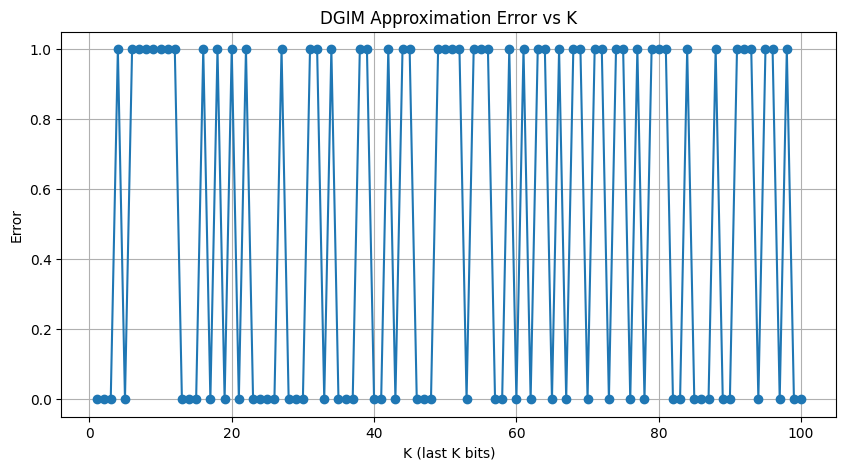

In [8]:
import random
import matplotlib.pyplot as plt
import pandas as pd
import time

class DGIM:
    def __init__(self, window_size=100):
        self.window_size = window_size
        self.buckets = []
        self.time = 0
        self.stream = []

    def _expire_old_buckets(self):
        self.buckets = [(s, t) for (s, t) in self.buckets if t > self.time - self.window_size]

    def _merge_buckets(self, max_buckets=2):
        i = 0
        while i < len(self.buckets) - max_buckets:
            if all(self.buckets[i][0] == self.buckets[i+j][0] for j in range(max_buckets+1)):
                new_bucket = (self.buckets[i][0]*2, self.buckets[i+1][1])
                del self.buckets[i:i+2]
                self.buckets.insert(i, new_bucket)
            else:
                i += 1

    def add_bit(self, bit: int, policy=2):
        self.time += 1
        self.stream.append(bit)

        if bit == 1:
            self.buckets.insert(0, (1, self.time))
            self._merge_buckets(policy)

        self._expire_old_buckets()

    def query(self, k: int):
        count = 0
        for i, (size, timestamp) in enumerate(self.buckets):
            start = timestamp - size + 1
            if start <= self.time - k:
                count += size // 2
                break
            else:
                count += size
        return count

# ---------------- ADVANCED TESTING ----------------

def run_partB():
    print("=== DGIM Algorithm: Part B (Advanced) ===")
    dgim = DGIM(window_size=100)

    # 1. Simulate bit stream
    N = 200
    stream = [random.choice([0,1]) for _ in range(N)]

    for b in stream:
        dgim.add_bit(b, policy=2)

    # 2. Multiple queries & error measurement
    queries = [10, 20, 50, 75, 100]
    results = []
    for k in queries:
        exact = sum(dgim.stream[-k:])
        approx = dgim.query(k)
        error = abs(exact - approx)
        results.append([k, exact, approx, error])

    df = pd.DataFrame(results, columns=["K", "Exact", "Approx", "Error"])
    print("\nQuery Results:")
    print(df)

    # 3. Error heatmap across K
    ks = range(1, dgim.window_size+1)
    errors = []
    for k in ks:
        exact = sum(dgim.stream[-k:])
        approx = dgim.query(k)
        errors.append(abs(exact - approx))

    plt.figure(figsize=(10,5))
    plt.plot(ks, errors, marker="o")
    plt.xlabel("K (last K bits)")
    plt.ylabel("Error")
    plt.title("DGIM Approximation Error vs K")
    plt.grid()
    plt.show()

if __name__ == "__main__":
    run_partB()
